# Lab 7 Instructions



In previous labs we used packet generator, switch port and packet sink modules from SimComponents.py file, in this lab we will use the RandomBrancher class from the same file to send packets along different routes. RandomBrancher is a demultiplexing component that selects the output port based on probability p. It maintains a list of output ports with the same length as the probability list provided during initialization. These output ports are used to establish connections with other network elements. 

In the following example, a packet generator is set up with changeable parameters for arrival rate and packet size. This generator is linked to a switch port and then a random brancher. The random brancher class is equipped with a list of probabilities that determine how traffic is directed to destination sinks 1 and 2 as shown in Figure below.

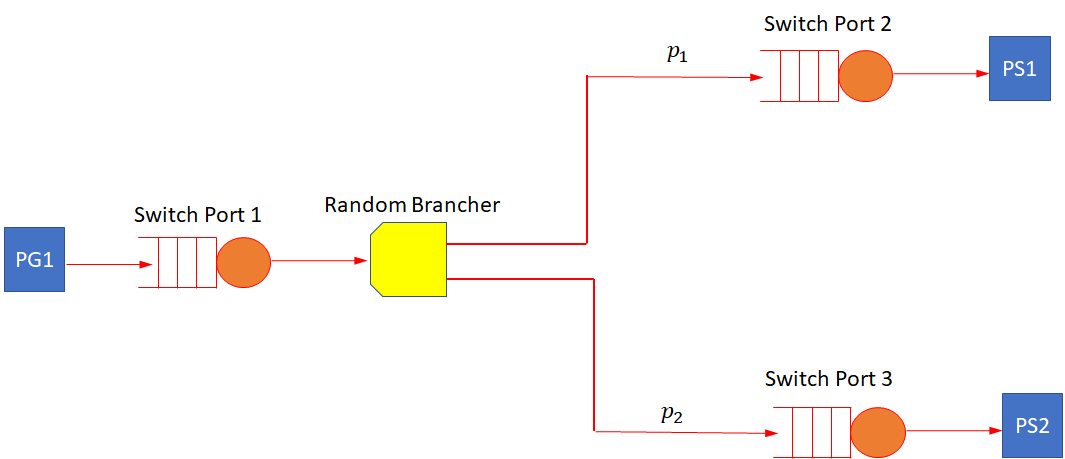

## Exercise 1

### Q1. Arrival Process, Random Branching, and Queue Classification


#### 1. Random Brancher Functionality

Examine the code for the Random Brancher in SimComponents.py.

Briefly explain the key functionality of the Random Brancher. describe

- how packets are received by the Random Brancher.

The random brancher exposes a put() method, which accepts a packet. The caller sends a packet by calling put(pkt). The method increments packets_rec, and then randomly allocate the input packet to one of the defined output ports.

- how packets are directed to different output paths.

When the random brancher is initialised with a list of probabilites, and it computes partial sumns from these. When put() is called, it draws a random number from [0, 1), and finds the first index i with rand < ranges[i]. That index is the chosen output, and the packet is forwarded to it.

- how the branching probabilities affect the number of packets received by each sink.

"probs" determines the cumulative "ranges" used for selection. Over many packets, we would expect the number delivered to sink i = probs[i] * total_packets (law of large numbers).

---

#### 2. Simulation Setup and Data Rate Calculation

Run the simulation using the code provided.

Enter values for:

- average packet size,
- arrival rate,
- switch port processing rate.

Calculate the data rate generated by `pk_gen_1` in bits per second using:

$$
\text{Data rate generated by PG1}
=
\lambda \times \text{Pkt\_size} \times 8
$$

where:

$$
\lambda = \text{arrival rate in packets/sec}
$$

and

$$
\text{Pkt\_size} = \text{average packet size in bytes}
$$

Then calculate the equivalent switch port rate for each processing rate \(P\):

$$
\text{Switch port rate}
=
P \times \text{Pkt\_size} \times 8
$$

where:

$$
P = \text{switch port processing rate in packets/sec}
$$

Run the simulation for:

$$
P = 2,\;4,\;6 \text{ packets/sec}
$$

Record your results in a table.
Using packet size = 10 bytes and lambda = 2 packets/sec

| Processing rate \(P\) packets/sec | Data rate generated by PG1 bits/sec | Switch port rate bits/sec | Average packet waiting time seconds |
|---|---:|---:|---:|
| 2 | 160 | 160 | 12.49 |
| 4 | 160 | 320 | 0.9 |
| 6 | 160 | 480 | 0.45 |

Based on your results, recommend a suitable value of \(P\) that keeps the average packet waiting time below:

$$
0.5 \text{ seconds}
$$

Briefly justify your recommendation.

Well clearly P = 6 packets/sec keeps the avg waiting time just below 0.5 s, so I'd pick that.

---

#### 3. Packet Counts, Waiting Times, and Routing Proportions

consider packet size is 10 bytes and arrival rate $\lambda$ in packets/sec is greater than the port processing rate For each value of:

$$
P = 2,\;4,\;6
$$

calculate and print the following values.

    - Calculate and print the total number of packets sent by `pk_gen_1`:
    - Calculate and print the number of packets received by each sink
    - Calculate and print the average waiting time for packets received at each sink:
    - Calculate and print the average waiting time for packets received at each sink:

For P=2,4,6, compute and compare the average queue size or system occupancy in bytes at:

    - switch_port1,
    - switch_port2,
    - switch_port3.

Briefly explain how the value of P affects queue build-up and packet delay.

Choose the smallest P that gives average packet waiting time below 0.5 seconds while avoiding excessive queue build-up or packet loss.


In [26]:
"""
Last modified on 07 May 2020 by Ahmet Sekercioglu.
Based on the original script by: Greg M. Bernstein
Revised 2024 and 2025 by Gayathri Kongara
Copyright 2014 Dr. Greg M. Bernstein
Released under the MIT license
"""

import random
import functools
import simpy
import numpy as np  # Added import for numpy
from SimComponents import PacketGenerator, PacketSink, SwitchPort, RandomBrancher, PortMonitor

def nanmean_list(seq):
    """Mean of sequence excluding NaNs/. Returns 0.0 if no valid values."""
    if not seq:
        return 0.0
    arr = np.array(seq, dtype=float)  # converts  to nan, non-numerics will error (as they should)
    valid = arr[~np.isnan(arr)]
    return float(valid.mean()) if valid.size > 0 else 0.0

def run_sim():
    # Set up arrival and packet size distributions
    mean_pkt_size = 10 # float(input("Enter average packet size in bytes: "))  # in bytes
    arrival_rate = 2 # float(input("Enter average arrival rate ( $\lambda_ $ packets/second): "))
    adist = functools.partial(random.expovariate, arrival_rate)
    sdist = functools.partial(random.expovariate, 1.0 / mean_pkt_size)
    samp_dist = functools.partial(random.expovariate, 1 / arrival_rate)  # monitor sampling gaps

    # Choose a port rate (in bits/sec) that samples at P packets per second
    port_rate = 480 #float(input("Choose a port rate (in bits/sec) that samples at P packets per second: "))
    # --- Get user input for probabilities ---
    p1 = 0.75 # float(input("Enter probability p1 (e.g., 0.75): "))
    p2 = 0.25 # float(input("Enter probability p2 (e.g., 0.25): "))

    # Create the SimPy environment. This is the simulation infrastructure.
    env = simpy.Environment()

    # Create the packet generators and sinks
    pk_gen_1 = PacketGenerator(env, "PG1", adist, sdist)
    pk_sink_1 = PacketSink(env, debug=False, rec_arrivals=True)
    pk_sink_2 = PacketSink(env, debug=False, rec_arrivals=True)
    branch1 = RandomBrancher(env, [p1, p2])
    switch_port1 = SwitchPort(env, port_rate)
    switch_port2 = SwitchPort(env, port_rate)
    switch_port3 = SwitchPort(env, port_rate)

    # Using a PortMonitor to track queue sizes over time
    pm1 = PortMonitor(env, switch_port1, samp_dist)
    pm2 = PortMonitor(env, switch_port2, samp_dist)
    pm3 = PortMonitor(env, switch_port3, samp_dist)
    
    # Wire packet generators, switch ports, and sinks together(Understanding of how to make
    pk_gen_1.out = switch_port1
    switch_port1.out = branch1
    branch1.outs[0] = switch_port2
    branch1.outs[1] = switch_port3
    switch_port2.out = pk_sink_1
    switch_port3.out = pk_sink_2

    # Initialize variables to store system occupancy
    system_occupancy1 = []
    system_occupancy2 = []
    system_occupancy3 = []
    sent = []
    # Run the simulation with recording system occupancy
    for time in range(1, 1000, 1):
        env.run(until=time)  # Run the simulation until the current time

        # Use NaN-calc  means for each monitor's sizes
        avg_occupancy1 = nanmean_list(pm1.sizes)
        avg_occupancy2 = nanmean_list(pm2.sizes)
        avg_occupancy3 = nanmean_list(pm3.sizes)

        system_occupancy1.append(avg_occupancy1)
        system_occupancy2.append(avg_occupancy2)
        system_occupancy3.append(avg_occupancy3)

    # --- compute and print average system occupancy ---
    def calc_mean(x):
        return float(np.mean(x)) if len(x) > 0 else 0.0

    avg_system_occ1 = calc_mean(system_occupancy1)
    avg_system_occ2 = calc_mean(system_occupancy2)
    avg_system_occ3 = calc_mean(system_occupancy3)
    total_avg_system_occ = avg_system_occ1 + avg_system_occ2 + avg_system_occ3

    print("\n========== Simulation Results ==========")     

    # Basic input information
    print(f"Average packet size = {mean_pkt_size:.2f} bytes")
    print(f"Arrival rate = {arrival_rate:.2f} packets/sec")
    print(f"Port rate = {port_rate:.2f} bits/sec")
    print(f"Branching probability p1 = {p1:.2f}")
    print(f"Branching probability p2 = {p2:.2f}")

    # ---------------------------------------------------------
    # TODO 1: Complete the equation for data rate generated by PG1
    #
    # ---------------------------------------------------------

    data_rate_pg1 = mean_pkt_size * arrival_rate * 8  # write eqn

    print("\n--- Data Rate Calculation ---")
    print(f"Data rate generated by PG1 = {data_rate_pg1:.2f} bits/sec")

    # ---------------------------------------------------------
    # TODO 2: Complete the equation for equivalent service rate
    # Service rate in packets/sec depends on port rate  and packet size in bits
    # ---------------------------------------------------------

    service_rate_packets_per_sec = port_rate / (mean_pkt_size * 8)  # write eqn

    print(f"Equivalent switch port processing rate = {service_rate_packets_per_sec:.2f} packets/sec")

    # ---------------------------------------------------------
    # TODO 3: Complete the packet count calculations
    # ---------------------------------------------------------

    sent = pk_gen_1.packets_sent        # Write eqn for total packets sent by pk_gen_1 (use .packets_sent member ... recall print(dir(pk_gen_1)) prints out 
                   # all members of the object)
    recv1 = len(pk_sink_1.waits)        # Write eqn for packets received by pk_sink_1 (.waits )
    recv2 = len(pk_sink_2.waits)        # Write eqn for packets received by pk_sink_2
    total_recv = recv1 + recv2     # Write eqn for total packets received

    print("\n--- Packet Counts ---")
    print(f"Packets sent by pk_gen_1 = {sent}")
    print(f"Packets received by pk_sink_1 = {recv1}")
    print(f"Packets received by pk_sink_2 = {recv2}")
    print(f"Total packets received = {total_recv}")

    # ---------------------------------------------------------
    # TODO 4: Complete the average waiting time calculations
    # ---------------------------------------------------------

    avg_wait_1 = np.nanmean(pk_sink_1.waits) if len(pk_sink_1.waits) > 0 else 0.0  # Write eqn for average waiting time to pk_sink_1 call nanmean_list definition 
    avg_wait_2 = np.nanmean(pk_sink_2.waits) if len(pk_sink_2.waits) > 0 else 0.0  # Write eqn for average waiting time to pk_sink_2 call nanmean_list definition 

    print("\n--- Average Waiting Times ---")
    print(f"Average waiting time to pk_sink_1 = {avg_wait_1:.4f} seconds")
    print(f"Average waiting time to pk_sink_2 = {avg_wait_2:.4f} seconds")

    # ---------------------------------------------------------
    # TODO 5: Complete the overall average waiting time
    # ---------------------------------------------------------

    all_waits = pk_sink_1.waits + pk_sink_2.waits           # Write eqn for combine waits from pk_sink_1 and pk_sink_2
    overall_avg_wait = np.nanmean(all_waits) if len(all_waits) > 0 else 0.0   # Write eqn for calculate average waiting time across both sinks

    print(f"Overall average waiting time = {overall_avg_wait:.4f} seconds")

    if overall_avg_wait < 0.5:
        print("Design criterion satisfied: average waiting time is less than 0.5 seconds.")
    else:
        print("Design criterion not satisfied: average waiting time is greater than or equal to 0.5 seconds.")

    # ---------------------------------------------------------
    # TODO 6: Complete the routing proportion calculations
    # ---------------------------------------------------------

    if sent > 0:
        p_hat_1 = recv1 / sent   # Write eqn for proportion of packets received by pk_sink_1 ratio of recv1 to total number of packets generated
        p_hat_2 = recv2 / sent   # Write eqn for proportion of packets received by pk_sink_2 ratio of recv2 to total number of packets generated
    else:
        p_hat_1 = 0.0
        p_hat_2 = 0.0

    print("\n--- Routing Proportions ---")
    print(f"Estimated proportion to pk_sink_1 = {p_hat_1:.4f}")
    print(f"Estimated proportion to pk_sink_2 = {p_hat_2:.4f}")

    # ---------------------------------------------------------
    # TODO 7: Complete the in-system packet calculations
    # Note that accounting for number of packets should take into account the ones in the queue and ones currently being served.
    # ---------------------------------------------------------

    in_sys_p1 = len(switch_port1.store.items) + switch_port1.busy  # Write eqn for packets in system at switch_port1
    in_sys_p2 = len(switch_port2.store.items) + switch_port2.busy  # Write eqn for packets in system at switch_port2
    in_sys_p3 = len(switch_port3.store.items) + switch_port3.busy  # Write eqn for packets in system at switch_port3

    in_system_total = in_sys_p1 + in_sys_p2 + in_sys_p3  # Write eqn for total packets still in the system

    # ---------------------------------------------------------
    # TODO 8: Complete the dropped packet calculation
    # ---------------------------------------------------------

    drops_total = switch_port1.packets_drop + switch_port2.packets_drop + switch_port3.packets_drop  # Write eqn for total dropped packets across all switch ports (switch_port1.packets_drop is for port 1...)

    print("\n--- Accounting Check ---")
    print(f"Sent = {sent}")
    print(f"Received = {total_recv}")
    print(f"In system = {in_system_total}")
    print(f"Dropped = {drops_total}")

    print(f"Check: {sent} ?= {total_recv} + {in_system_total} + {drops_total}")

    if sent == total_recv + in_system_total + drops_total:
        print("Accounting check is satisfied.")
    else:
        print("Accounting check is not satisfied.")

    print("\nPackets still in the system:")
    print(f"switch_port1 = {in_sys_p1}")
    print(f"switch_port2 = {in_sys_p2}")
    print(f"switch_port3 = {in_sys_p3}")

    print("\nPackets dropped:")
    print(f"switch_port1 drops = {switch_port1.packets_drop}")
    print(f"switch_port2 drops = {switch_port2.packets_drop}")
    print(f"switch_port3 drops = {switch_port3.packets_drop}")

    # Average queue/system occupancy
    print("\n--- Average System Occupancy ---")
    print(f"Average system occupancy at switch_port1 = {avg_system_occ1:.4f} bytes")
    print(f"Average system occupancy at switch_port2 = {avg_system_occ2:.4f} bytes")
    print(f"Average system occupancy at switch_port3 = {avg_system_occ3:.4f} bytes")
    print(f"Total average system occupancy = {total_avg_system_occ:.4f} bytes")

    print("========================================\n")

   
    
if __name__ == '__main__':
    run_sim()



========== Simulation Results ==========
Average packet size = 10.00 bytes
Arrival rate = 2.00 packets/sec
Port rate = 480.00 bits/sec
Branching probability p1 = 0.75
Branching probability p2 = 0.25

--- Data Rate Calculation ---
Data rate generated by PG1 = 160.00 bits/sec
Equivalent switch port processing rate = 6.00 packets/sec

--- Packet Counts ---
Packets sent by pk_gen_1 = 1922
Packets received by pk_sink_1 = 1433
Packets received by pk_sink_2 = 487
Total packets received = 1920

--- Average Waiting Times ---
Average waiting time to pk_sink_1 = 0.4580 seconds
Average waiting time to pk_sink_2 = 0.4107 seconds
Overall average waiting time = 0.4460 seconds
Design criterion satisfied: average waiting time is less than 0.5 seconds.

--- Routing Proportions ---
Estimated proportion to pk_sink_1 = 0.7456
Estimated proportion to pk_sink_2 = 0.2534

--- Accounting Check ---
Sent = 1922
Received = 1920
In system = 2
Dropped = 0
Check: 1922 ?= 1920 + 2 + 0
Accounting check is satisfied.


## Exercise 2

In this exercise, you will explore a simplifed engineering faculty (our fictitious faculty has three departments only) computer network diagram as a queueing network. The diagram is shown below:
Data generated from three packet generators representing different departments (pg1, pg2, pg3) traverse through a series of switch ports before reaching their respective destinations at one of the three campuses: Malaysia, Caulfield, and Peninsula. Each packet generator is connected to a switch port (sw_port1, sw_port2, and sw_port3). The network topology includes three random branches (branch1, branch2, branch3 and branch 4), each linked to two switch ports (sw_port4, sw_port5, sw_port6, and sw_port7). Incoming packets at these random branches are directed to one of the switch ports (sw_port4, sw_port5, sw_port6, and sw_port7) based on a probability 0 and 1. Finally, the packets are transmitted to the packet sink at the destination campuses located in Malaysia, Caulfield, and Peninsula.

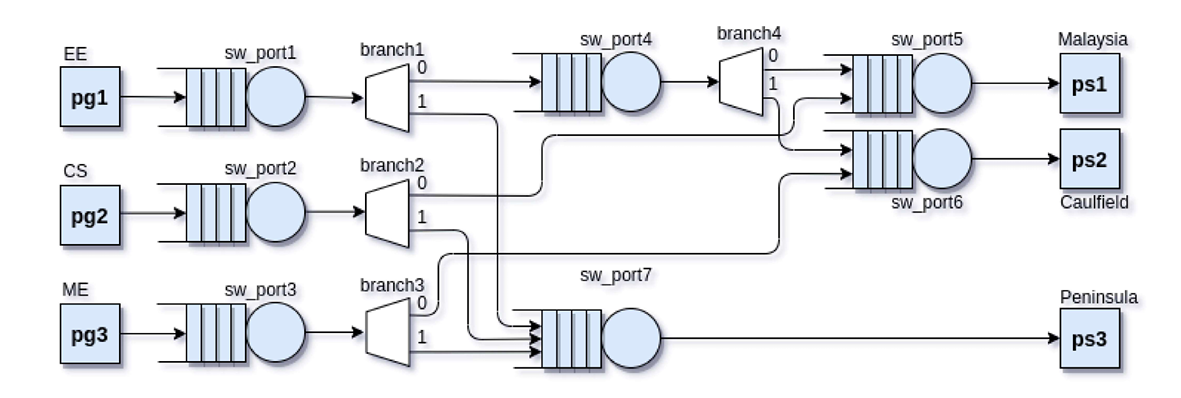

1. Draw an image of PG as rectangles and switch ports circles and draw a picture indicating the probabilities. Complete the Random brancher code for all four branches based on probabilities defined below

These lines of code set up four different random branching mechanisms, each representing a LAN (Local Area Network) within a simulated network environment. Each LAN generates network traffic, and the branching mechanisms determine how this traffic is distributed to different destinations within the network.

    1. **`branch1` (EE LAN):**
   - 70% of the traffic generated by the EE LAN is destined to Malaysia and Caulfield Campuses (in aggregate).
   - Probability distribution: [0.7, 0.3]
   
    2. **`branch2` (CS LAN):**
   - 40% of the traffic generated by CS LAN goes to Malaysia Campus.
   - Probability distribution: [0.4, 0.6]
   - This implies that 40% of the packets will be forwarded to Malaysia Campus.

    3. **branch3 (ME LAN):**
   - 55% of the traffic generated by ME LAN finds its way to Peninsula Campus.
   - Probability distribution: [0.45, 0.55]
   - This indicates that 55% of the packets will be forwarded to Peninsula Campus.

    4. **`branch4`:**
   - packets a will be forwarded to Malaysia Campus (65%) and Caulfield Campus (35%)., but the probability distribution is 
     [0.65, 0.35].
 
2. The number of packets generated is stored in pk_gen_1.packets_sent, print in the code below cases

    1. The number of packets generated by the EE (Electrical Engineering) source.
    2. The number of packets generated by the CS (Computer Science source).
    3. The number of packets generated by the ME (Mechanical Engineering) source.

    The wait times at pk_sink_1 are stored in the parameter pk_sink_1.waits print in the code below cases
    4. The average wait time for packets at `pk_sink_1`.
    5. The average wait time for packets at `pk_sink_2`.
    6. The average wait time for packets at `pk_sink_3`.


    7. The total number of packets sent by all sources combined.
    8. The total number of packets received at `pk_sink_1`.
    9. The total number of packets received at `pk_sink_2`.
    10. The total number of packets received at `pk_sink_3`.
    
3. Run the code and show your output to lab demonstrator.

4. How do the average waits at each sink change as you vary mean_pkt_size while keeping arrival rates fixed? Explain with queueing intuition.

As the packet size increases, the mean wait times increase. This is obvious. Each packet takes longer to serve/process if it is larger, so if any packets queue up they needs to wait for all those before them to be serviced before they can be.

5. Increase the arrival rate of one department at a time. Which switch port becomes the bottleneck first, and why?

None of them significantly changed the wait times or bottlenecked them up to arrival rate = 500, and my simulation was taking over 1 minute to run. I don't have time for this trial and error type of question.



In [ ]:

import random
import functools
import simpy
import numpy as np

from SimComponents import PacketGenerator, PacketSink, SwitchPort, RandomBrancher

def run_sim():
    # Set up arrival and packet size distributions
    mean_pkt_size = 1000 # float(input("Packet Size in bytes: "))  # in bytes
    arrival_rate1 = 20 #  float(input("Enter arrival rate from EE dept: "))
    arrival_rate2 = 20 # float(input("Enter arrival rate from CS dept: "))
    arrival_rate3 = 20 # float(input("Enter arrival rate from ME dept: "))

    adist1 = functools.partial(random.expovariate, arrival_rate1)
    adist2 = functools.partial(random.expovariate, arrival_rate2)
    adist3 = functools.partial(random.expovariate, arrival_rate3)
    sdist = functools.partial(random.expovariate, 1.0 / mean_pkt_size)
    samp_dist = functools.partial(random.expovariate, 0.50)
    port_rate = 100 * 10**6  # 100 Mbits/sec in bits/sec

    # Create the SimPy environment
    env = simpy.Environment()

    # Create the packet generators and sink
    pk_gen_1 = PacketGenerator(env, "EE", adist1, sdist)
    pk_gen_2 = PacketGenerator(env, "CS", adist2, sdist)
    pk_gen_3 = PacketGenerator(env, "ME", adist3, sdist)

    pk_sink_1 = PacketSink(env, debug=False, rec_arrivals=True)
    pk_sink_2 = PacketSink(env, debug=False, rec_arrivals=True)
    pk_sink_3 = PacketSink(env, debug=False, rec_arrivals=True)
    
    #Input probabilities here
    # Input routing probabilities
    p14 = 0.7 # float(input("Enter p14: probability from switch_port1 to switch_port4: "))
    p17 = 1.0 - p14

    p25 = 0.4 # float(input("Enter p25: probability from switch_port2 to switch_port5: "))
    p26 = 1.0 - p25

    p36 = 0.45 # float(input("Enter p36: probability from switch_port3 to switch_port6: "))
    p37 = 1.0 - p36

    p45 = 0.65 # float(input("Enter p45: probability from switch_port4 to switch_port5: "))
    p46 = 1.0 - p45
    branch1 = RandomBrancher(env, [p14, p17]) #Input aprropriate probabilities
    branch2 = RandomBrancher(env, [p25, p26]) #Input aprropriate probabilities
    branch3 = RandomBrancher(env, [p36, p37]) #Input aprropriate probabilities
    branch4 = RandomBrancher(env, [p45, p46]) #Input aprropriate probabilities
        
    switch_port1 = SwitchPort(env, port_rate)
    switch_port2 = SwitchPort(env, port_rate)
    switch_port3 = SwitchPort(env, port_rate)
    switch_port4 = SwitchPort(env, port_rate)
    switch_port5 = SwitchPort(env, port_rate)
    switch_port6 = SwitchPort(env, port_rate)
    switch_port7 = SwitchPort(env, port_rate)
    
    # Wire packet generators, switch ports, and sinks together
    pk_gen_1.out = switch_port1
    pk_gen_2.out = switch_port2
    pk_gen_3.out = switch_port3

    switch_port1.out = branch1
    switch_port2.out = branch2
    switch_port3.out = branch3
    switch_port4.out = branch4
    
    branch1.outs[0] = switch_port4
    branch1.outs[1] = switch_port7

    branch2.outs[0] = switch_port5
    branch2.outs[1] = switch_port6

    branch3.outs[0] = switch_port6
    branch3.outs[1] = switch_port3
    
    branch4.outs[0] = switch_port5
    branch4.outs[1] = switch_port6
    
    switch_port5.out = pk_sink_1
    switch_port6.out = pk_sink_2
    switch_port7.out = pk_sink_3
    
    # Run the simulation
    env.run(until=5000)

    # Print statements here
    print(f"Number of packets generated by EE source: {pk_gen_1.packets_sent}")
    print(f"Number of packets generated by CS source: {pk_gen_2.packets_sent}")
    print(f"Number of packets generated by ME source: {pk_gen_3.packets_sent}")
    print(f"Average wait time at pk_sink_1: {np.mean(pk_sink_1.waits) if pk_sink_1.waits else 0}")
    print(f"Average wait time at pk_sink_2: {np.mean(pk_sink_2.waits) if pk_sink_2.waits else 0}")
    print(f"Average wait time at pk_sink_3: {np.mean(pk_sink_3.waits) if pk_sink_3.waits else 0}")
    print(f"Total packets sent by all sources: {pk_gen_1.packets_sent + pk_gen_2.packets_sent + pk_gen_3.packets_sent}")
    print(f"Total packets received at pk_sink_1: {len(pk_sink_1.arrivals)}")
    print(f"Total packets received at pk_sink_2: {len(pk_sink_2.arrivals)}")
    print(f"Total packets received at pk_sink_3: {len(pk_sink_3.arrivals)}")

if __name__ == '__main__':
    run_sim()


Number of packets generated by EE source: 79682
Number of packets generated by CS source: 80558
Number of packets generated by ME source: 1999517
Average wait time at pk_sink_1: 0.00020287785418361857
Average wait time at pk_sink_2: 0.00028146836283636045
Average wait time at pk_sink_3: 0.00016033041167259497
Total packets sent by all sources: 2159757
Total packets received at pk_sink_1: 68828
Total packets received at pk_sink_2: 2067064
Total packets received at pk_sink_3: 23865


## Exercise 2

For the offered link loads of 10%, 20% and 30% of the Ethernet link capacities (i.e. 100 Mbits/sec) at the departmental LANs (packet generators), run your simulation for 5000 seconds to average wait times at PS1 PS2 and PS3 at  Malaysia , Caulfield and Penincula Campuses, respectively. 


# Jackson-style Network
## Exercise 3 -OPTIONAL
Jackson Network Assumptions

A Jackson network is usually based on the following assumptions:

- external arrivals follow Poisson processes,
- service times are exponentially distributed,
- routing between queues is probabilistic and independent,
- queues are stable,
- packets eventually leave the system in an open network.

For the given simulation, discuss whether each assumption is satisfied.

Complete the table below.

| Jackson network assumption | Is it satisfied in this code? | Explanation |
|---|---|---|
| External arrivals are Poisson |  |  |
| Service times are exponential |  |  |
| Routing is probabilistic |  |  |
| The network is open |  |  |
| Feedback is allowed and accounted for |  |  |
| Each queue is stable |  |  |

---

#### Traffic Equations

Let the external arrival rates be:

$$
\lambda_{\text{EE}}, \lambda_{\text{CS}}, \lambda_{\text{ME}}
$$

Let the routing probabilities be:

$$
p_{14}, p_{17}, p_{25}, p_{26}, p_{36}, p_{33}, p_{45}, p_{46}
$$

Write the traffic equations for the arrival rate into each switch port.

For example:

$$
\lambda_1 = \lambda_{\text{EE}}
$$

$$
\lambda_2 = \lambda_{\text{CS}}
$$

Because `switch_port3` has a feedback path back to itself, its traffic equation is:

$$
\lambda_3 = \lambda_{\text{ME}} + p_{33}\lambda_3
$$

Rearrange this equation to obtain:

$$
\lambda_3 = \frac{\lambda_{\text{ME}}}{1-p_{33}}
$$

Then write expressions for:

$$
\lambda_4,\;\lambda_5,\;\lambda_6,\;\lambda_7
$$

---

#### Stability Condition

The approximate service rate of each switch port is:

$$
\mu = \frac{\text{port rate}}{\text{mean packet size} \times 8}
$$

For the network to be stable, each queue should satisfy:

$$
\rho_i = \frac{\lambda_i}{\mu} < 1
$$

Using your calculated values of \( \lambda_i \), determine whether each switch port is stable.

Complete the table below.

| Switch port | Arrival rate \( \lambda_i \) | Service rate \( \mu \) | Traffic intensity \( \rho_i \) | Stable? |
|---|---:|---:|---:|---|
| 1 |  |  |  |  |
| 2 |  |  |  |  |
| 3 |  |  |  |  |
| 4 |  |  |  |  |
| 5 |  |  |  |  |
| 6 |  |  |  |  |
| 7 |  |  |  |  |

---

#### Finally

Based on your analysis, answer the following question:

**Can this simulation be truly viewed as a Jackson network, or should it only be described as a Jackson-style queueing network?**

In your answer, refer to:

- Poisson arrivals,
- exponential service times,
- probabilistic routing,
- 

- queue stability,
- end-of-simulation packets still in the system.

Write a short conclusion 




<div style="background: linear-gradient(90deg, #e8fff1, #e8f4ff); border: 2px solid #4caf50; border-radius: 12px; padding: 18px; text-align: center;">

<h2 style="color: #2e7d32;">🎉 CONGRATULATIONS! 🎉</h2>

<h3 style="color: #1565c0;">You successfully completed the Lucky Last Lab.</h3>

<p style="font-size: 18px; color: #444;">
Well done on completing the simulation, analysing the queueing behaviour, and checking the Jackson-style network assumptions.
</p>

</div>